# Research: citation graph → communities (`research_2 copy.ipynb`)

**Part A** — BigQuery citation edges (or **synthetic** `cwts_synthetic_test/` when `RESEARCH2_SYNTHETIC=1`), optional **NetworkX** plot on a **2000-edge sample**, and a small custom label-propagation demo (not CWTS).

Use **`research_2.ipynb`** for the BigQuery-only workflow without the synthetic switch.

**Part B** — **[CWTS publicationclassification](https://github.com/CWTSLeiden/publicationclassification)** on the **full** `df`: multi-resolution **Leiden** clusters (micro / meso / macro) from the same query as Part A (or from the synthetic fixture).

Run cells top to bottom. Part B needs a JDK and the CWTS repo built (`gradlew.bat build`). For the small synthetic graph, the notebook uses lower resolution / min-cluster thresholds automatically when `RESEARCH2_SYNTHETIC` is set.


In [ ]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# Synthetic test data (no BigQuery): set env RESEARCH2_SYNTHETIC=1 or flip to True below.
RESEARCH2_SYNTHETIC = os.environ.get("RESEARCH2_SYNTHETIC", "").lower() in (
    "1",
    "true",
    "yes",
)
# RESEARCH2_SYNTHETIC = True  # uncomment to always use cwts_synthetic_test/


def _notebook_dir_data() -> Path:
    cwd = Path.cwd()
    for d in (cwd, cwd / "2026" / "Scope drift oksana"):
        if (d / "research_2 copy.ipynb").exists() or (d / "research_2.ipynb").exists():
            return d.resolve()
    return cwd.resolve()


NOTEBOOK_DIR_DATA = _notebook_dir_data()

if RESEARCH2_SYNTHETIC:
    client = None
else:
    from google.cloud import bigquery

    client = bigquery.Client(project="ocean-breeze-tier-1")

In [12]:
if RESEARCH2_SYNTHETIC:
    _fix = NOTEBOOK_DIR_DATA / "cwts_synthetic_test"
    _cit = _fix / "cit_links.txt"
    if not _cit.is_file():
        raise FileNotFoundError(
            f"Missing {_cit}. Run: python {_fix / 'generate_fixture.py'}"
        )
    _edges = pd.read_csv(
        _cit,
        sep="\t",
        header=None,
        names=["PublicationId", "CitedPublicationId", "cit_weight"],
    )
    df = _edges[["PublicationId", "CitedPublicationId"]].astype(int)
    print("Using synthetic fixture:", _fix, "| directed edges:", len(df))
else:
    query = """

SELECT
  pc.PublicationId,
  pc.CitedPublicationId,
  p.Title
  -- t.FieldOfStudyId,
  -- t.FieldOfStudyName,
  -- t.Similarity
FROM `ocean-breeze-tier-1.airak.PublicationCitation` pc
JOIN `airak.Publication` p
  ON pc.PublicationId = p.PublicationId

WHERE p.PublishedYear = 2025
AND p.JournalId IN (2336462209025, 1589137899520)
--AND t.FieldOfStudyId = 8735168
ORDER BY pc.PublicationId


"""

    query = query_job = client.query(query)
    results = query_job.result()

    df = results.to_dataframe()

c:\Users\sophie.wilson\AppData\Local\miniconda3\envs\scope_drift\lib\site-packages\google\cloud\bigquery\table.py:1965: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [13]:
edges = list(zip(df["PublicationId"], df["CitedPublicationId"]))
# or: edges = df[["PublicationId", "CitedPublicationId"]].itertuples(index=False, name=None)

print(edges[:10])

[(957889382828978, 17180443567), (957889382828978, 1606318303654), (957889382828978, 1709399057196), (957889382828978, 498216748678), (957889382828978, 438087127672), (957889382828978, 1116691678910), (957889382828978, 371463138100678), (957889382828978, 33165743942713), (957889382828978, 1623498187237), (957889382828978, 42950255223)]


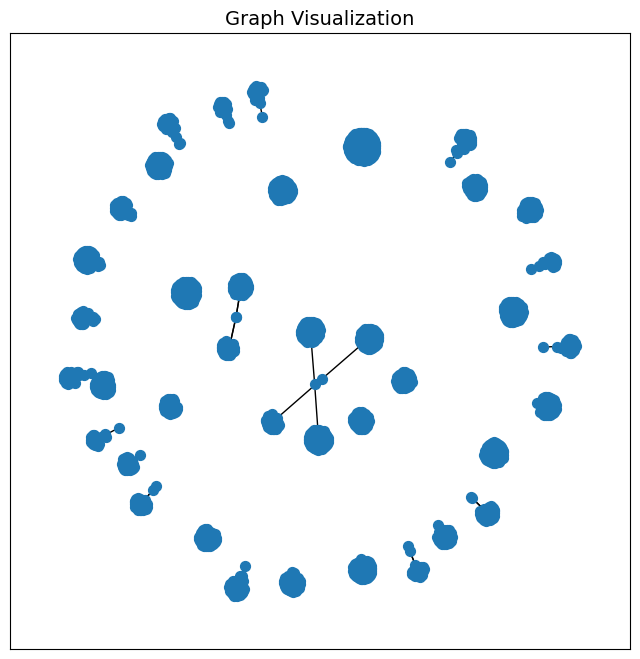

In [ ]:
# Create the graph and add the edges
graph = nx.Graph()
graph.add_edges_from(edges[:2000])

# Improve the visualization with a layout and better styling
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(graph, seed=42)  # Use a seed for consistent layout

# Draw the graph with additional details
nx.draw_networkx(
    graph,
    pos,
    with_labels=False,
    # node_color="lightblue",
    node_size=50,
    # font_size=1,
    # font_color="black",
    # edge_color="gray",
)

# # Show the graph
plt.title("Graph Visualization", fontsize=14)
plt.show()

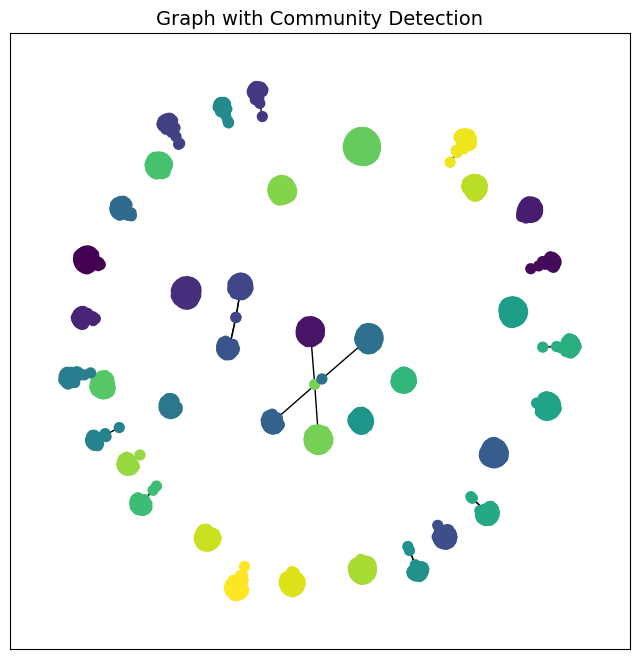

In [15]:
# Step 1: Initialize each node in its own community
communities = {node: node for node in graph.nodes()}


# Step 2: Define a function to calculate modularity gain
def modularity_gain(graph, communities, node, target_community):
    internal_edges = sum(
        1
        for neighbor in graph.neighbors(node)
        if communities[neighbor] == target_community
    )
    return internal_edges


# Step 3: Iteratively move nodes to maximize modularity
for _ in range(10):  # Arbitrary number of iterations
    nodes = list(graph.nodes())
    random.shuffle(nodes)
    for node in nodes:
        best_community = communities[node]
        max_gain = 0
        for neighbor in graph.neighbors(node):
            target_community = communities[neighbor]
            gain = modularity_gain(graph, communities, node, target_community)
            if gain > max_gain:
                best_community = target_community
                max_gain = gain
        communities[node] = best_community


# Assign colors based on the community each node belongs to
unique_communities = list(set(communities.values()))
color_map = {community: i for i, community in enumerate(unique_communities)}
node_colors = [color_map[communities[node]] for node in graph.nodes()]

# Draw the graph with communities highlighted
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(graph, seed=42)
nx.draw_networkx(
    graph,
    pos,
    with_labels=False,
    arrows=True,
    node_color=node_colors,
    node_size=50,
    cmap=plt.colormaps["viridis"].resampled(max(len(unique_communities), 1)),
)

# Title and display the graph
plt.title("Graph with Community Detection", fontsize=14)
plt.show()

## Part B: CWTS publication-level communities (Leiden)

Part A loads a **citation edge list** in `df` and explores a small **NetworkX** subgraph.

This section runs **[CWTS publicationclassification](https://github.com/CWTSLeiden/publicationclassification)** on the **full** Part A edge list (BigQuery **or** synthetic `cwts_synthetic_test/` when `RESEARCH2_SYNTHETIC` is set): it builds the directed citation network, runs the **Leiden** algorithm, and writes **micro / meso / macro** cluster IDs per publication (see the upstream README for methodology).

**Requirements:** JDK on `PATH` or `JAVA_HOME` set. **Gradle:** wrapper is **8.2.x** (use JDK **17–21**; env **`GRADLE_JAVA_HOME`** if your default JDK is newer). **CWTS `java` run:** large graphs may need more RAM; default **`-Xmx8g`** (override with env **`CWTS_JVM_OPTS`**, e.g. `-Xmx16g -XX:+ExitOnOutOfMemoryError`). Clone path: **`PUBLICATION_CLASSIFICATION_ROOT`**.


In [ ]:
# %pip install -q pandas pyarrow
from __future__ import annotations

import os
import shutil
import subprocess
from pathlib import Path

import pandas as pd

PUBLICATION_CLASSIFICATION_ROOT = Path(
    os.environ.get(
        "PUBLICATION_CLASSIFICATION_ROOT",
        r"C:\Users\sophie.wilson\publicationclassification",
    )
)


def _notebook_dir() -> Path:
    cwd = Path.cwd()
    for d in (cwd, cwd / "2026" / "Scope drift oksana"):
        if (d / "research_2 copy.ipynb").exists() or (d / "research_2.ipynb").exists():
            return d.resolve()
    return cwd.resolve()


NOTEBOOK_DIR = _notebook_dir()
WORK_DIR = NOTEBOOK_DIR / "_cwts_work"
WORK_DIR.mkdir(parents=True, exist_ok=True)

COL_CORE_ID = "publication_id"
COL_CITING = "citing_publication_id"
COL_CITED = "cited_publication_id"
COL_WEIGHT = "cit_weight"

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("WORK_DIR:", WORK_DIR)

NOTEBOOK_DIR: C:\Users\sophie.wilson\OneDrive - Frontiers Media SA\Repos\Sophie\2026\Scope drift oksana
WORK_DIR: C:\Users\sophie.wilson\OneDrive - Frontiers Media SA\Repos\Sophie\2026\Scope drift oksana\_cwts_work


In [ ]:
# Build CWTS tab-separated inputs from Part A `df` (or copy synthetic fixture when RESEARCH2_SYNTHETIC)
import shutil

PUBS_TSV = WORK_DIR / "pubs.txt"
CITS_TSV = WORK_DIR / "cit_links.txt"
CLASS_OUT = WORK_DIR / "classification.txt"

if RESEARCH2_SYNTHETIC:
    _fix = NOTEBOOK_DIR / "cwts_synthetic_test"
    shutil.copy2(_fix / "pubs.txt", PUBS_TSV)
    shutil.copy2(_fix / "cit_links.txt", CITS_TSV)
    n = len(pd.read_csv(PUBS_TSV, sep="\t", header=None))
    all_ids = list(range(n))
    _nc = len(pd.read_csv(CITS_TSV, sep="\t", header=None))
    print("Synthetic: copied fixture ->", WORK_DIR, "| pubs", n, "| cit rows", _nc)
else:
    df_edges = df.rename(
        columns={"PublicationId": COL_CITING, "CitedPublicationId": COL_CITED}
    ).copy()
    df_edges[COL_WEIGHT] = 1.0
    df_core = (
        df[["PublicationId"]]
        .drop_duplicates()
        .rename(columns={"PublicationId": COL_CORE_ID})
    )

    def norm_pub_id(x) -> int | None:
        if pd.isna(x):
            return None
        return int(x)

    core_ids = {
        norm_pub_id(v) for v in df_core[COL_CORE_ID] if norm_pub_id(v) is not None
    }

    df_e = df_edges[[COL_CITING, COL_CITED, COL_WEIGHT]].copy()
    df_e["_src"] = df_e[COL_CITING].map(norm_pub_id)
    df_e["_tgt"] = df_e[COL_CITED].map(norm_pub_id)
    df_e = df_e.dropna(subset=["_src", "_tgt"])
    df_e["_src"] = df_e["_src"].astype(int)
    df_e["_tgt"] = df_e["_tgt"].astype(int)
    df_e = df_e[df_e["_src"] != df_e["_tgt"]]

    edge_endpoints = set(df_e["_src"].tolist()) | set(df_e["_tgt"].tolist())
    all_ids = sorted(edge_endpoints | core_ids)
    pub_map = {pid: idx for idx, pid in enumerate(all_ids)}

    pub_rows = [(pub_map[pid], 1 if pid in core_ids else 0) for pid in all_ids]
    pubs_df = pd.DataFrame(pub_rows, columns=["pub_no", "core_pub"])

    agg = (
        df_e.groupby(["_src", "_tgt"], as_index=False)[COL_WEIGHT]
        .sum()
        .rename(columns={"_src": "raw_src", "_tgt": "raw_tgt"})
    )
    agg["pub_no1"] = agg["raw_src"].map(pub_map)
    agg["pub_no2"] = agg["raw_tgt"].map(pub_map)
    agg = agg.dropna(subset=["pub_no1", "pub_no2"])
    agg["pub_no1"] = agg["pub_no1"].astype(int)
    agg["pub_no2"] = agg["pub_no2"].astype(int)
    agg = agg.sort_values(["pub_no1", "pub_no2"])
    # CWTS loads citations with Network(..., sortedEdges=True): each undirected edge must appear
    # twice (both directions), globally sorted by (pub_no1, pub_no2). One row per direction only → odd nEdges / error.
    _forward = agg[["pub_no1", "pub_no2", COL_WEIGHT]].copy()
    _reverse = pd.DataFrame(
        {
            "pub_no1": _forward["pub_no2"].values,
            "pub_no2": _forward["pub_no1"].values,
            COL_WEIGHT: _forward[COL_WEIGHT].values,
        }
    )
    _bidir = pd.concat([_forward, _reverse], ignore_index=True)
    cit_df = (
        _bidir.groupby(["pub_no1", "pub_no2"], as_index=False)[COL_WEIGHT]
        .sum()
        .sort_values(["pub_no1", "pub_no2"])
        .rename(columns={COL_WEIGHT: "cit_weight"})
    )

    pubs_df.to_csv(PUBS_TSV, sep="\t", header=False, index=False)
    cit_df.to_csv(CITS_TSV, sep="\t", header=False, index=False)

    print("Wrote", PUBS_TSV, "rows", len(pubs_df))
    print("Wrote", CITS_TSV, "rows", len(cit_df))

Wrote C:\Users\sophie.wilson\OneDrive - Frontiers Media SA\Repos\Sophie\2026\Scope drift oksana\_cwts_work\pubs.txt rows 142529
Wrote C:\Users\sophie.wilson\OneDrive - Frontiers Media SA\Repos\Sophie\2026\Scope drift oksana\_cwts_work\cit_links.txt rows 362430


In [ ]:
def _find_cwts_jars(jar_dir: Path) -> list[Path]:
    if not jar_dir.is_dir():
        return []
    jars = []
    for p in jar_dir.glob("*.jar"):
        if p.name.endswith("-sources.jar") or p.name.endswith("-javadoc.jar"):
            continue
        jars.append(p)
    pref = [p for p in jars if p.name.startswith("publicationclassification")]
    return pref or jars


def _java_env_info() -> dict:
    jh = os.environ.get("JAVA_HOME", "").strip()
    java_home_exe = Path(jh) / "bin" / "java.exe" if jh else None
    return {
        "java_which": shutil.which("java"),
        "JAVA_HOME": jh or None,
        "java_home_exe_exists": java_home_exe.is_file() if java_home_exe else False,
    }


def _java_usable() -> bool:
    info = _java_env_info()
    return bool(info["java_which"]) or bool(info["java_home_exe_exists"])


def _java_executable() -> str:
    info = _java_env_info()
    if info["java_which"]:
        return info["java_which"]
    jh = os.environ.get("JAVA_HOME", "").strip()
    p = Path(jh) / "bin" / "java.exe"
    if p.is_file():
        return str(p)
    raise RuntimeError(
        "Cannot find java.exe. Install a JDK, add it to PATH, or set JAVA_HOME to the JDK root."
    )


JAR_DIR = PUBLICATION_CLASSIFICATION_ROOT / "build" / "libs"
GRADLEW = PUBLICATION_CLASSIFICATION_ROOT / "gradlew.bat"

jars = _find_cwts_jars(JAR_DIR)
if not jars and GRADLEW.is_file():
    if not _java_usable():
        raise RuntimeError(
            "JDK not found for Gradle. Add Java to PATH or set JAVA_HOME, then restart the Jupyter kernel."
        )
    # Gradle 8.2.x in CWTS does not run on very new JDKs (e.g. 25). Use JDK 17 or 21 for the build.
    _gradle_env = os.environ.copy()
    _gjh = os.environ.get("GRADLE_JAVA_HOME", "").strip()
    if _gjh:
        _gradle_env["JAVA_HOME"] = _gjh
    _gradle = subprocess.run(
        ["cmd.exe", "/c", "gradlew.bat", "build"],
        cwd=str(PUBLICATION_CLASSIFICATION_ROOT),
        env=_gradle_env,
        capture_output=True,
        text=True,
        encoding="utf-8",
        errors="replace",
    )
    if _gradle.returncode != 0:
        _err = _gradle.stderr or ""
        _hint = ""
        if "Unsupported class file major version" in _err:
            _hint = (
                "\n\nYour default JDK is too new for the CWTS Gradle wrapper (8.2.x). "
                "Install Eclipse Temurin JDK 17 or 21, then either: (1) set user env JAVA_HOME to that JDK "
                "and restart the kernel, or (2) set GRADLE_JAVA_HOME to that JDK root (folder containing bin\\java.exe) "
                "so only the Gradle build uses it."
            )
        raise RuntimeError(
            "gradlew.bat build failed (exit %s). Stderr tail:\n%s%s"
            % (_gradle.returncode, _err[-4000:], _hint)
        )
    jars = _find_cwts_jars(JAR_DIR)

if not jars:
    raise FileNotFoundError(
        f"No CWTS JAR in {JAR_DIR}. Run `gradlew.bat build` in your clone, "
        f"or set env PUBLICATION_CLASSIFICATION_ROOT. "
        f"See https://github.com/CWTSLeiden/publicationclassification"
    )

jar_path = max(jars, key=lambda p: p.stat().st_mtime)

LARGEST_COMPONENT = "true"
if RESEARCH2_SYNTHETIC:
    N_ITER = "50"
    RES_MICRO, THR_MICRO = "0.02", "3"
    RES_MESO, THR_MESO = "0.01", "3"
    RES_MACRO, THR_MACRO = "0.005", "3"
else:
    N_ITER = "100"
    RES_MICRO, THR_MICRO = "4e-4", "25"
    RES_MESO, THR_MESO = "2e-4", "250"
    RES_MACRO, THR_MACRO = "7e-5", "1000"

MAIN = "nl.cwts.publicationclassification.run.PublicationClassificationCreator"

import shlex

_jvm_default = "-Xmx8g -XX:+ExitOnOutOfMemoryError"
JVM_OPTS = shlex.split(os.environ.get("CWTS_JVM_OPTS", _jvm_default))

cmd = [
    _java_executable(),
    *JVM_OPTS,
    "-cp",
    str(jar_path),
    MAIN,
    str(PUBS_TSV),
    str(CITS_TSV),
    str(CLASS_OUT),
    LARGEST_COMPONENT,
    N_ITER,
    RES_MICRO,
    THR_MICRO,
    RES_MESO,
    THR_MESO,
    RES_MACRO,
    THR_MACRO,
]

print("CWTS JAR:", jar_path.name, "JVM:", " ".join(JVM_OPTS))
_cwts = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
)
if _cwts.returncode != 0:
    _hint = ""
    if _cwts.returncode in (-1, 4294967295) or "OutOfMemoryError" in (
        _cwts.stderr or ""
    ):
        _hint = (
            "\n\nLarge graphs often need more heap. Set env CWTS_JVM_OPTS e.g. "
            '"-Xmx16g -XX:+ExitOnOutOfMemoryError" (quoted as one var on Windows) and restart the kernel.'
        )
    raise RuntimeError(
        "CWTS java failed (exit %s). Stderr:\n%s%s"
        % (_cwts.returncode, (_cwts.stderr or "")[-6000:], _hint)
    )
print("Wrote", CLASS_OUT)

CWTS JAR: publicationclassification-1.1.0-1-g0894840.jar JVM: -Xmx8g -XX:+ExitOnOutOfMemoryError
Wrote C:\Users\sophie.wilson\OneDrive - Frontiers Media SA\Repos\Sophie\2026\Scope drift oksana\_cwts_work\classification.txt


In [ ]:
# Join CWTS cluster labels back to publication IDs (same order as prep cell)
idx_to_pub = all_ids

cls_df = pd.read_csv(
    CLASS_OUT,
    sep="\t",
    header=None,
    names=["pub_no", "micro_cluster", "meso_cluster", "macro_cluster"],
)
cls_df["publication_id"] = cls_df["pub_no"].map(lambda i: idx_to_pub[int(i)])

# CWTS uses cluster IDs starting at 0. If nunique is 1 per level, the whole LCC is one community at that scale.
for _c in ("micro_cluster", "meso_cluster", "macro_cluster"):
    print(
        f"{_c}: nunique={cls_df[_c].nunique()}  min={cls_df[_c].min()}  max={cls_df[_c].max()}"
    )

print(cls_df.shape)
cls_df.head(10)

micro_cluster: nunique=1  min=0  max=0
meso_cluster: nunique=1  min=0  max=0
macro_cluster: nunique=1  min=0  max=0
(139320, 5)


,pub_no,micro_cluster,meso_cluster,macro_cluster,publication_id
0,0,0,0,0,0
1,1,0,0,0,1
2,2,0,0,0,3
3,3,0,0,0,13
4,4,0,0,0,41
5,5,0,0,0,55
6,6,0,0,0,69
7,7,0,0,0,78
8,8,0,0,0,84
9,9,0,0,0,87


In [ ]:
# Part B visualization: colour citation subgraph by CWTS cluster
# Requires the SAME kernel state as the CWTS prep cell: `df`, `cls_df`, `all_ids` from one consistent run.
CLUSTER_COL = "meso_cluster"  # or "micro_cluster" / "macro_cluster"

# Remap pub_no → publication_id from current `all_ids` (avoids stale cls_df["publication_id"] if cells were re-run out of order).
_mx = int(cls_df["pub_no"].max())
if _mx >= len(all_ids):
    raise IndexError(
        f"cls_df pub_no max={_mx} but len(all_ids)={len(all_ids)}. "
        "Re-run the prep cell (builds all_ids + TSVs) then Java, then the cls_df load cell."
    )
_cls_pid = cls_df.assign(
    publication_id=cls_df["pub_no"].astype(int).map(lambda i: int(all_ids[i]))
)
node_attr = _cls_pid[["publication_id", CLUSTER_COL]].drop_duplicates(
    subset=["publication_id"]
)

g = nx.from_pandas_edgelist(
    df,
    source="PublicationId",
    target="CitedPublicationId",
    create_using=nx.DiGraph,
)

nodes_g = {int(n) for n in g.nodes()}
labeled = {int(x) for x in node_attr["publication_id"]}
common = labeled & nodes_g
print(
    f"Viz overlap: {len(common)} IDs in both CWTS output and df graph "
    f"(cls {len(labeled)} ids, graph {len(nodes_g)} nodes)"
)
if len(common) == 0:
    raise ValueError(
        "No publication IDs overlap between cls_df (via all_ids[pub_no]) and df graph nodes. "
        "Usually: re-run top-to-bottom — same BigQuery `df` → prep (pubs/cit_links + all_ids) → Java → load cls_df — "
        "without swapping in a different `df` or stale `all_ids`."
    )

g = g.subgraph([n for n in g.nodes() if int(n) in common]).copy()

# Random edge sampling on a huge sparse graph gives ~degree-1 nodes → many tiny components → "nothing connects".
# Take the largest weakly connected piece, then an ego neighborhood around a hub so the plot is one connected blob.
SAMPLE_EDGES = 2500
ug_full = g.to_undirected()
if ug_full.number_of_edges() == 0:
    raise ValueError(
        "No edges among overlapping nodes. df may list no edges between papers that CWTS classified "
        "(check that the same `df` built cit_links.txt)."
    )
lcc_nodes = max(nx.connected_components(ug_full), key=len)
ug = ug_full.subgraph(lcc_nodes).copy()
hub = max(ug.nodes(), key=ug.degree)
radius = 1
eg = nx.ego_graph(ug, hub, radius=radius)
while eg.number_of_edges() < min(SAMPLE_EDGES, ug.number_of_edges()) and radius < 12:
    radius += 1
    eg = nx.ego_graph(ug, hub, radius=radius)
if eg.number_of_edges() > SAMPLE_EDGES:
    while eg.number_of_edges() > SAMPLE_EDGES and radius > 1:
        radius -= 1
        eg = nx.ego_graph(ug, hub, radius=radius)

g_plot = eg

clus = dict(zip(node_attr["publication_id"].astype(int), node_attr[CLUSTER_COL]))
nx.set_node_attributes(
    g_plot, {n: clus.get(int(n), -1) for n in g_plot.nodes()}, CLUSTER_COL
)

vals = [g_plot.nodes[n][CLUSTER_COL] for n in g_plot.nodes()]
pos = nx.spring_layout(g_plot, seed=42, k=0.25, iterations=50)

print(
    f"Plotted subgraph: {g_plot.number_of_nodes()} nodes, {g_plot.number_of_edges()} edges, "
    f"{nx.number_connected_components(g_plot)} connected component(s) (undirected)"
)

plt.figure(figsize=(12, 10))
nx.draw_networkx_edges(g_plot, pos, alpha=0.35, width=0.8)
nc = nx.draw_networkx_nodes(
    g_plot,
    pos,
    node_size=14,
    node_color=vals,
    cmap="tab20",
    alpha=0.9,
)
plt.colorbar(nc, label=CLUSTER_COL, shrink=0.6)
plt.title(f"Citation subgraph (LCC + ego r≤{radius}) coloured by CWTS {CLUSTER_COL}")
plt.axis("off")
plt.tight_layout()
plt.show()

Viz overlap: 617 IDs in both CWTS output and df graph (cls 139320 ids, graph 158059 nodes)


ValueError: No edges among overlapping nodes. df may list no edges between papers that CWTS classified (check that the same `df` built cit_links.txt).